**Integración numérica**

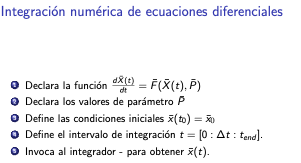

Se utiliza para calcular soluciones aproximadas a integrales o resolver ecuaciones diferenciales cuando no se dispone de soluciones analíticas exactas.

La integración numérica en biología de sistemas es una herramienta computacional que permite simular la evolución temporal de sistemas biológicos complejos. En este campo, los modelos matemáticos (por ejemplo, ecuaciones diferenciales) se utilizan para describir procesos como interacciones entre genes, proteínas o reacciones metabólicas. Sin embargo, muchas de estas ecuaciones no tienen soluciones analíticas (es decir, fórmulas exactas), por lo que se recurre a métodos numéricos para aproximar la solución a lo largo del tiempo.

**¿Por qué es importante en biología de sistemas?**

**Modelado de procesos complejos:**
Permite predecir cómo evolucionarán las concentraciones de moléculas, la actividad de genes o la interacción entre poblaciones, entre otros procesos biológicos, bajo diferentes condiciones o perturbaciones.

**Estudio de dinámicas no lineales:**
Muchos sistemas biológicos presentan comportamientos no lineales y retroalimentaciones complejas. La integración numérica ayuda a explorar estos comportamientos cuando las soluciones analíticas no son posibles.

**Validación y experimentación virtual:**
Al simular modelos computacionales, los investigadores pueden comparar las predicciones con datos experimentales, probar hipótesis y explorar escenarios que serían difíciles o costosos de recrear en el laboratorio.


**Para resolver ecuaciones diferenciales ordinarias (EDO)**

**Método de Euler:**
Es el más básico y sencillo. Se calcula la solución en pasos discretos, aunque puede requerir pasos muy pequeños para alcanzar precisión adecuada.

**Métodos de Runge-Kutta:**
En particular, el método RK4 (cuarta orden) es muy popular porque ofrece un buen equilibrio entre precisión y coste computacional. Existen variantes de orden superior y métodos adaptativos que ajustan el tamaño del paso.

**Métodos multistep:**
Como los métodos Adams-Bashforth y Adams-Moulton, que utilizan información de pasos previos para predecir la solución en el siguiente paso, permitiendo a menudo mayor eficiencia.

**Métodos implícitos (por ejemplo, Backward Euler y BDF):**
Son especialmente útiles para sistemas rígidos, donde las soluciones pueden variar en escalas muy diferentes y se requiere estabilidad numérica.



**librería deSolve:**

Permite llevar a cabo la integración numérica de sistemas de ecuaciones diferenciales

**La función LVmodel recibe tres argumentos:**

**t:** el tiempo actual (necesario para la integración, aunque en este caso las ecuaciones no dependen explícitamente del tiempo).
state: un vector que contiene las poblaciones actuales de presas (𝑥) y depredadores (𝑦).parameters: un vector con los parámetros del modelo.

Dentro de la función, se extraen las variables de estado y los parámetros, y se calculan las derivadas según las ecuaciones del modelo Lotka-Volterra. La función devuelve un listado con las derivadas.

**Especificación de los parámetros:**
Se asignan valores a los parámetros 
𝛼, 𝛽, 𝛾 y 𝛿. Estos controlan el crecimiento, la depredación, la mortalidad y la conversión de presas en depredadores, respectivamente.

**Condiciones iniciales:**
Se define el estado inicial del sistema, estableciendo la población inicial de presas en 40 y la de depredadores en 9.

**Intervalo de integración:**
Se genera una secuencia de tiempos desde 0 hasta 50, con incrementos de 0.1, para los cuales se calcularán las soluciones del sistema.

**Integración numérica:**
La función ode integra el sistema utilizando el método de resolución numérica y almacena los resultados en el objeto out.

**Graficación:**
Finalmente, se grafica la evolución temporal de ambas poblaciones. Se utiliza plot para dibujar la curva de las presas y lines para añadir la curva de los depredadores, diferenciándolas con colores y agregando una leyenda.

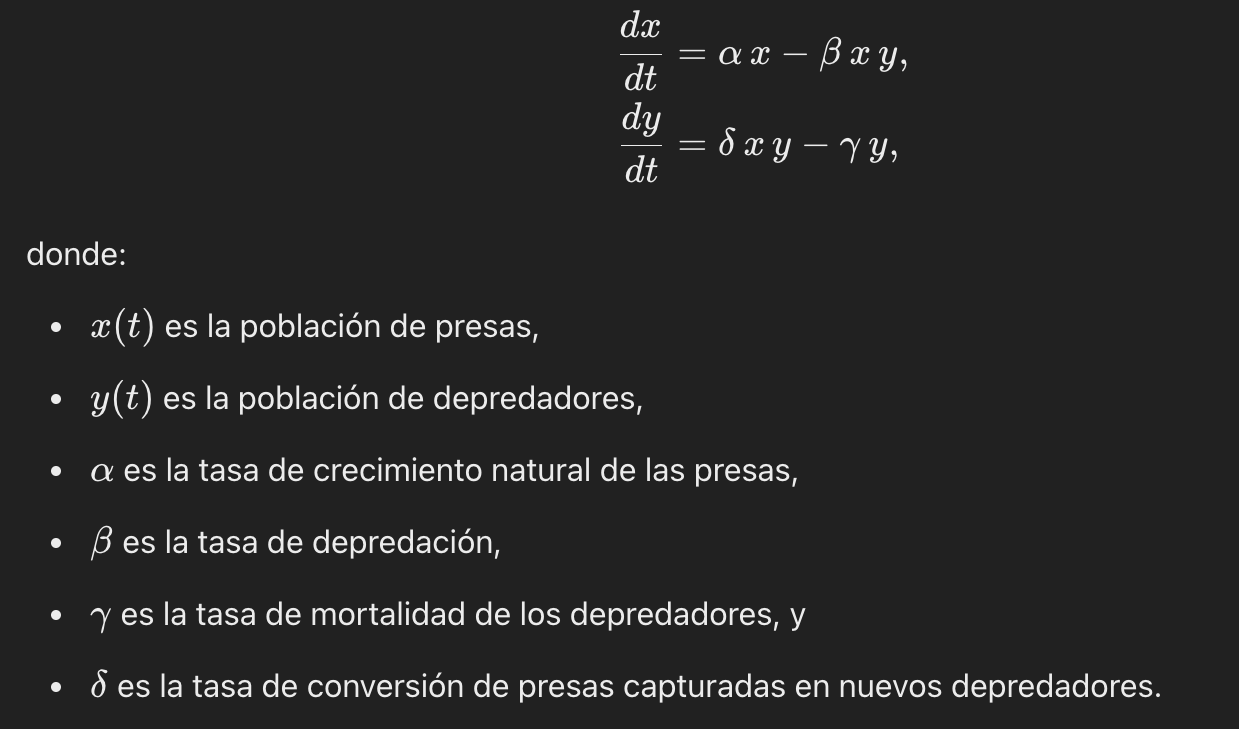



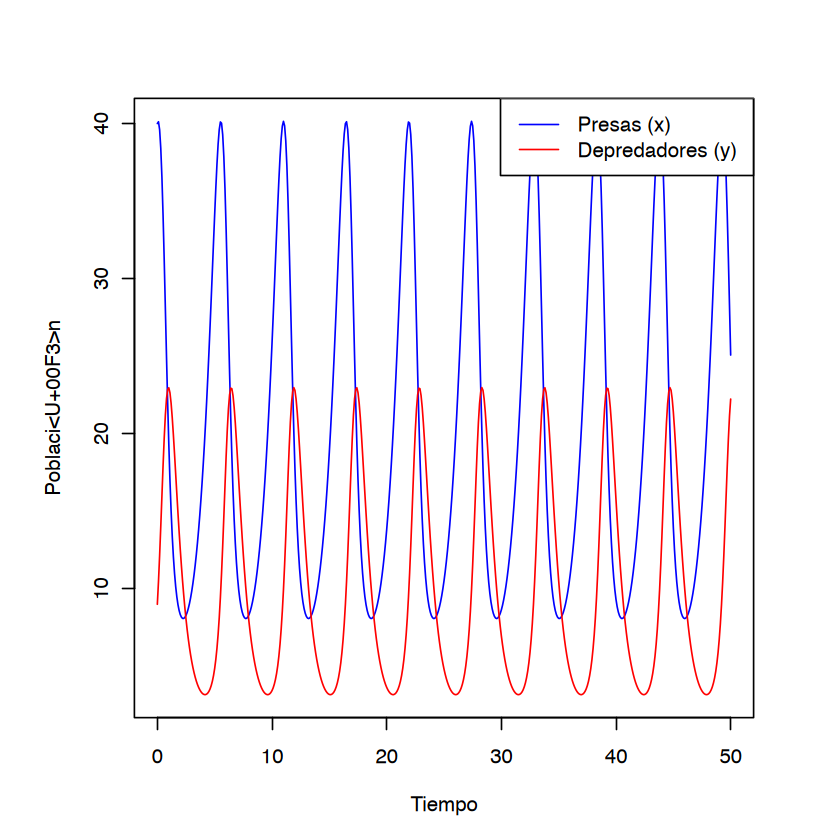

In [1]:
library(deSolve)

# (1) Definición de la función del modelo Lotka-Volterra
LVmodel <- function(t, state, parameters) {
  # state: vector con las variables de estado: x (presas) y y (depredadores)
  # parameters: vector con los parámetros del modelo
  x <- state[1]
  y <- state[2]
  
  alpha <- parameters["alpha"]
  beta  <- parameters["beta"]
  gamma <- parameters["gamma"]
  delta <- parameters["delta"]
  
  # Ecuaciones diferenciales del modelo:
  dx <- alpha * x - beta * x * y         # Crecimiento de presas menos depredación
  dy <- delta * x * y - gamma * y          # Reproducción de depredadores menos mortalidad
  
  list(c(dx, dy))
}

# (2) Declaración de los parámetros del modelo
parameters <- c(alpha = 1.0,   # Tasa de crecimiento de presas
                beta  = 0.1,   # Tasa de depredación
                gamma = 1.5,   # Tasa de mortalidad de depredadores
                delta = 0.075) # Tasa de conversión de presas en depredadores

# (3) Condiciones iniciales: poblaciones iniciales de presas y depredadores
state0 <- c(x = 40,  # Número inicial de presas
            y = 9)   # Número inicial de depredadores

# (4) Definición del intervalo de integración
times <- seq(0, 50, by = 0.1)

# (5) Integración numérica del sistema de ecuaciones
out <- ode(y = state0, times = times, func = LVmodel, parms = parameters)

# (6) Graficación de los resultados
# Se extraen las columnas correspondientes al tiempo, presas (x) y depredadores (y)
par(pty = "s")
plot(out[, "time"], out[, "x"], type = "l", col = "blue", 
     xlab = "Tiempo", ylab = "Población", ylim = range(out[, c("x", "y")]))
lines(out[, "time"], out[, "y"], col = "red")
legend("topright", legend = c("Presas (x)", "Depredadores (y)"), 
       col = c("blue", "red"), lty = 1)


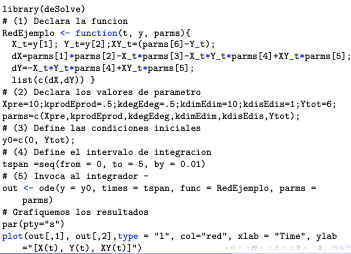

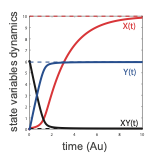

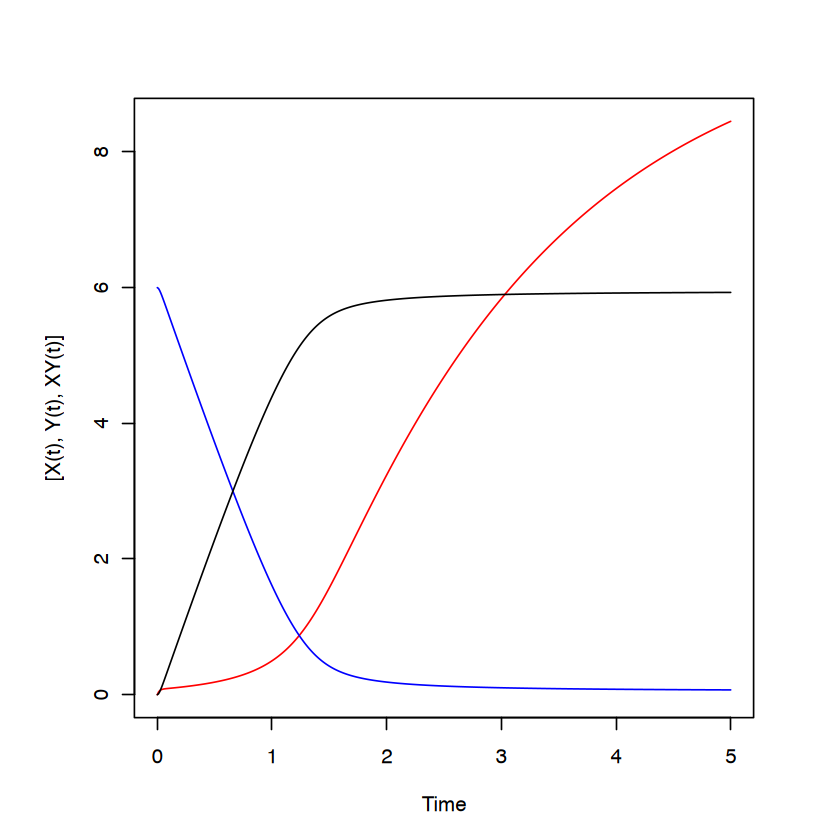

In [2]:
library(deSolve)


#######
# (1) Declaramos la función $\frac{d\bar{X}(t)}{dt}=\bar{F}(\bar{X}(t), \bar{P})$

RedEjemplo <- function(t, y, parms){  
  # parametros
        #  1        2           3       4         5        6   
  #parms=(Xpre, kprodEprod, kdegEdeg, kdimEdim, kdisEdis, Ytot)
  # Variables de estado
  
  X_t=y[1]; 
  Y_t=y[2];
  XY_t=(parms[6]-Y_t);
  dX <- parms[1]*parms[2]-X_t*parms[3]-X_t*Y_t*parms[4]+XY_t*parms[5];
  dY <- -X_t*Y_t*parms[4]+XY_t*parms[5];
  list(c(dX,dY))
}

# (2) Declaramos los valores de parametro $\bar{P}$
Xpre=10; kprodEprod=.5; kdegEdeg=.5; kdimEdim=10; kdisEdis=1;
Ytot=6;
parms=c(Xpre, kprodEprod, kdegEdeg, kdimEdim, kdisEdis, Ytot);

# (3) Definimos las condiciones iniciales $\bar{x}(t_0)=\bar{x}_{\rm 0}$
y0=c(0, Ytot);

# (4) Definimos el intervalo de integración númerica $t=[0:\Delta t:t_{end}]$.
tspan =seq(from = 0, to = 5, by = 0.01) 

# DEL TIEMPO T=0 AL T=5 CON PASOS DE 0.01 (DELTA T=0.01)
# DELTA T NOS PERMITE CONTROLAR LA PRECISION DE LA INTEGRACION SI ES MAS O MENOS PRECISA

# (5) Invoca al integrador - para obtener $\bar{x}(t)$.  
# A integrar!

out <- ode(y = y0, times = tspan, func = RedEjemplo, parms = parms)

# Graficamos los resultados
par(pty="s")
plot(out[,1], out[,2],type = "l", col="red", xlab = "Time", ylab ="[X(t), Y(t), XY(t)]")
lines(out[,1], out[,3],type = "l", col="blue")
lines(out[,1], Ytot-out[,3],type = "l", col="black")
legend=c("X(t)", "Y(t)", "XY(t)")


OBTENEMOS LAS TRAYECTORIAS DINAMICAS DE LAS VARIABLES DE ESTADO DADAS CIERTAS CONDICIONES INICIALES. A TIEMPOS LARGOS SE PARECEN A LAS SOLUCIONES DE EQUILIBRIO (CAMBIAR T=5 A TIEMPOS MAS LARGOS PARA VER COMO SE PARECEN A LAS SOLUCIONES DE EQUILIBRIO). POR EJEMPLO X TARDA MAS EN RELAJARSE Y LLEGAR A SU EQUILIBRIO

**OPTIMIZACIÓN PARAMETRICA**

El segundo paso es la **optimización parametrica**, durante la optimización paramétrica, se ajustan los parámetros iterativamente, evaluando en cada paso la solución obtenida a partir de la integración numérica, para que el modelo se ajuste a los datos o a los criterios de desempeño establecidos.

La optimización paramétrica consiste en encontrar el conjunto de parámetros, $\vec{p}$, en el modelo que permiten tener la menor discrepancia entre los datos y la simulación hecha con el modelo. 



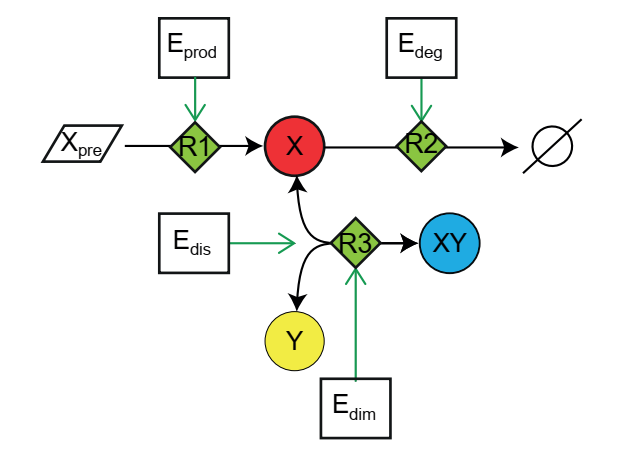

Cargando paquete requerido: rootSolve

Cargando paquete requerido: coda



grind.R was sourced


x          y         xy 
6.23121864 0.09521706 5.90478294

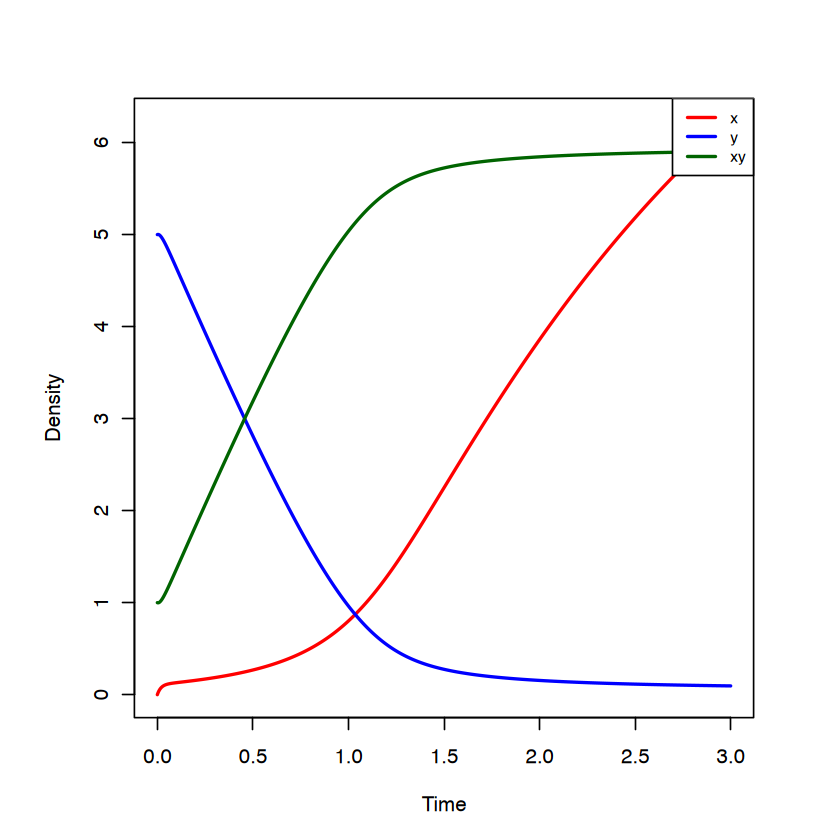

In [3]:
# instalar librerías
#install.packages("deSolve")
#install.packages("FME")
#install.packages("rootSolve")

library(deSolve)
library(FME)
library(rootSolve)
# cargar Grind.R
source("Grind.R")

# establecer modelo (Grind trabaja con el nombre del modelo "model" por default)
model <- function(time, state, parms) {
        with(as.list(c(state,parms)),{
                
                dx <- xpre*kprodEprod - x*kdegEdeg - x*y*kdimEdim + (ytot-y)*kdisEdis
                dy <- - x*y*kdimEdim + (ytot-y)*kdisEdis
                dxy <- - dy
                return(list(c(dx, dy, dxy)))
        })
}

# declarar primer estimación para los parámetros
# (Grind trabaja con el nombre del vector de parámetros "p" por default)
p <- c(xpre = 10, kprodEprod = 0.5, kdegEdeg = 0.5, kdimEdim = 10, kdisEdis = 1, ytot = 6)

# Establecer condiciones iniciales (las cuales, efectivamente, son parámetros)
# (Grind trabaja con el nombre del vector de condiciones iniciales "s" por default)
s <- c(x = 0, y = 5, xy = 1)

# simulación numérica
par(pty="s") # axis square
run(parms=p, state = s, tstep=0.001, tmax=3)

En resumen, necesitamos tener la integración numérica implementada y funcionando para poder evaluar cada conjunto de parámetros durante el proceso de optimización.

Este problema se puede establecer asi:

$
\text{Minimizar:} 
$
$$
\hspace{0.5cm} Costo(\vec{p}) = \sum_i^n \left(\vec{x}_{pred,i} - \vec{x}_{exp,i} \right)^2 
$$

$
\text{Sujeto a:}
$
$$
\frac{d\vec{x}(t)}{dt} = F(\vec{x(t)},\vec{p}) 
$$

$$
\hspace{1.5cm}\vec{x}(0) = \vec{x}_0
$$

Por lo tanto para la optimización paramétrica requerimos un conjunto de datos experimentales con observaciones de las variables en el modelo, en este caso $X$, $Y$ o $XY$

SSR: 5.217439  Estimates:
kdimEdim     ytot 
194.4601 250.7684 


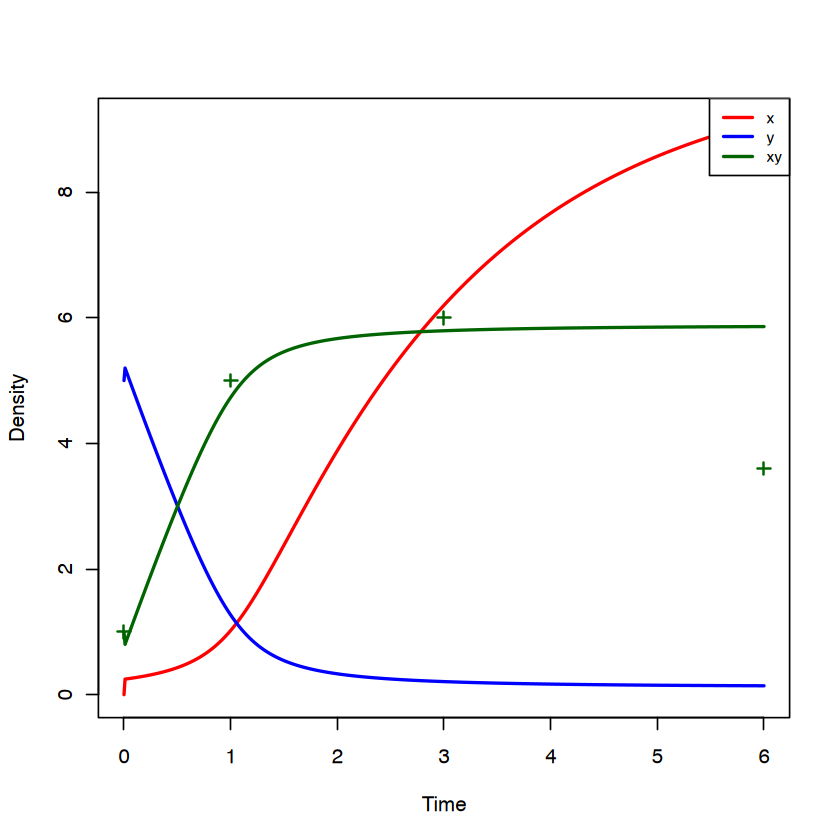

In [4]:
# introducir datos experimentales
t_exp <- c(0, 1, 3, 6)
xy_exp <- c(0.5, 2.5, 3, 1.8)/0.5 
# guardar en un dataframe (necesario para usar la función fit()). 
# los nombres de las variables en el dataframe deben ser igual a sus nombres en el modelo
data <- data.frame(time = t_exp, xy = xy_exp)

# correr la optimización
w <- c("kdimEdim", "ytot") # w contiene los nombres de los parámetros libres
f <- fit(free = w, tstep = 0.01)

In [5]:
# revisar error estándar, estadístico t, valor p, etc.
summary(f)


Parameters:
         Estimate Std. Error t value Pr(>|t|)   
kdimEdim   194.46      26.06   7.461   0.0175 * 
ytot       250.77      19.51  12.856   0.0060 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.615 on 2 degrees of freedom

Parameter correlation:
         kdimEdim    ytot
kdimEdim   1.0000 -0.9513
ytot      -0.9513  1.0000

In [6]:
# es posible revisar los resultados del ejemplo con f$par
f$par

kdimEdim     ytot 
194.4601 250.7684

In [7]:
# obtener la suma de los cuadrados del error
f$ssr

[1] 5.217439

In [8]:
# los parámetros sin optimizar son
p

xpre kprodEprod   kdegEdeg   kdimEdim   kdisEdis       ytot 
      10.0        0.5        0.5       10.0        1.0        6.0

In [9]:
# guardar un vector con los parámetros óptimos
p_opt=p
p_opt[4]=f$par[1]
p_opt[6]=f$par[2]
p_opt

xpre kprodEprod   kdegEdeg   kdimEdim   kdisEdis       ytot 
   10.0000     0.5000     0.5000   194.4601     1.0000   250.7684

x         y        xy 
6.1985686 0.2079206 5.7920794

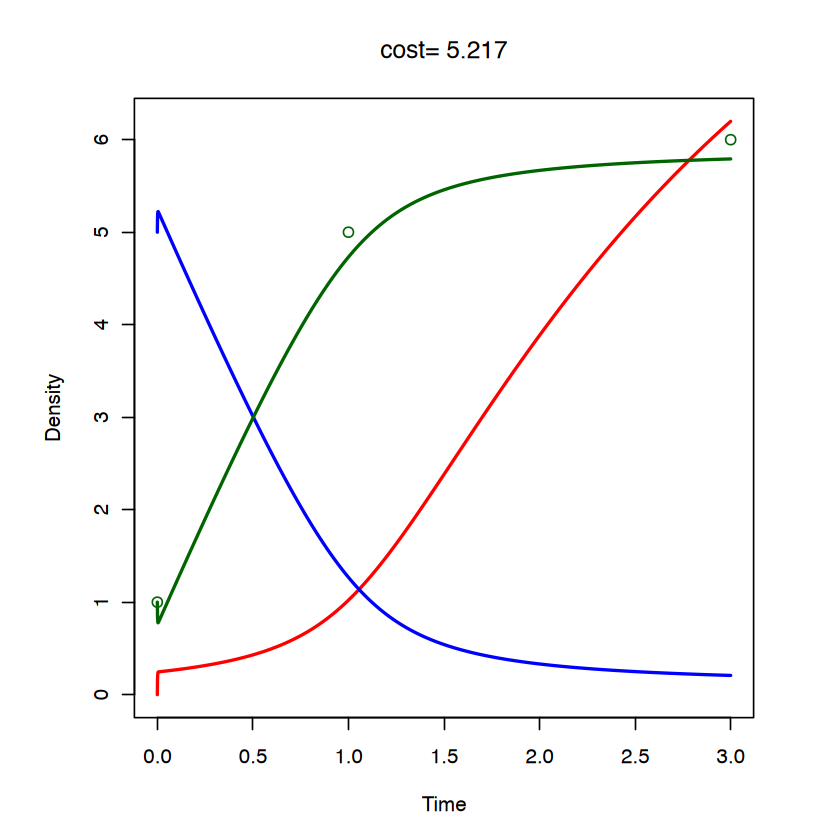

In [10]:
# simular con los parámetros óptimos y comparar con los datos experimentales 
par(pty="s") # axis square
run(parms=p_opt, legend=FALSE, tstep=0.001, tmax=3, 
    main=c(paste("cost=", toString(round(f$ssr, digits = 3) ), sep=" ")))
points(t_exp, xy_exp, col="darkgreen", lty=5)

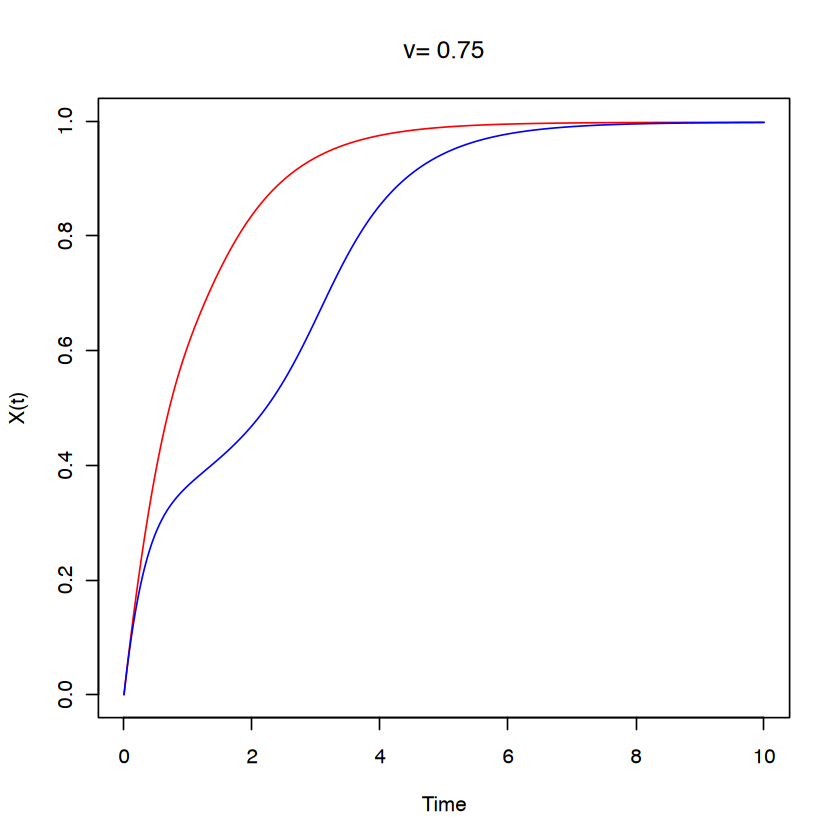

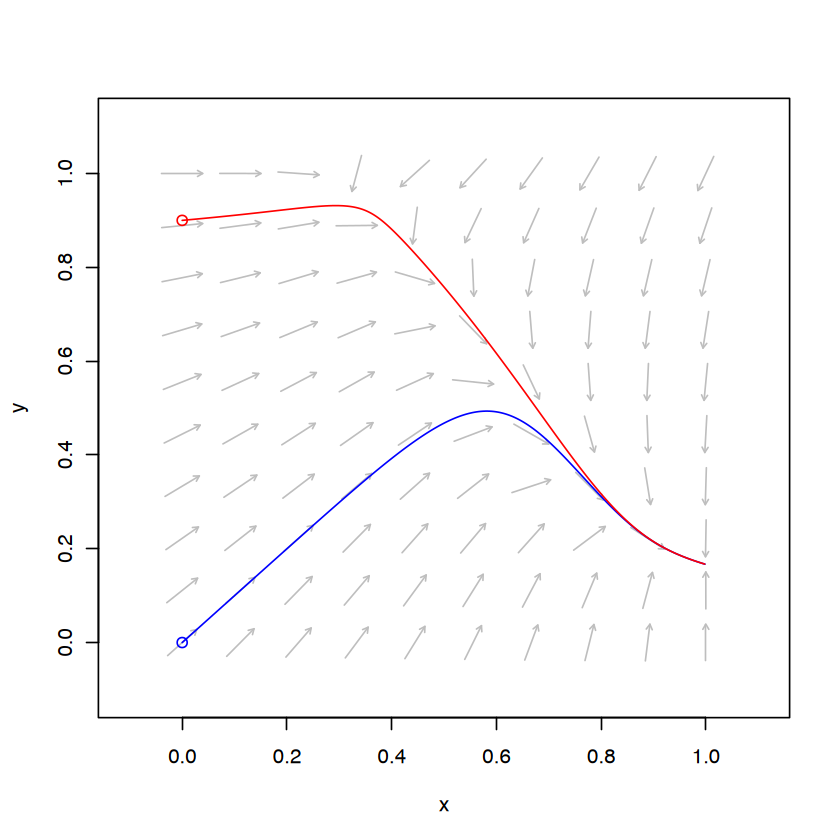

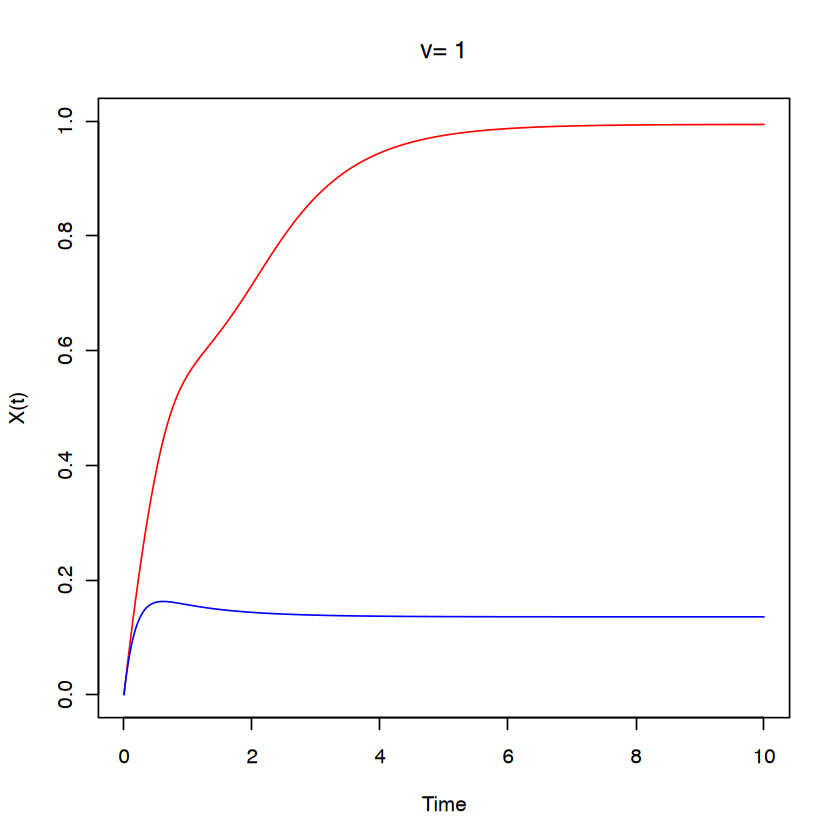

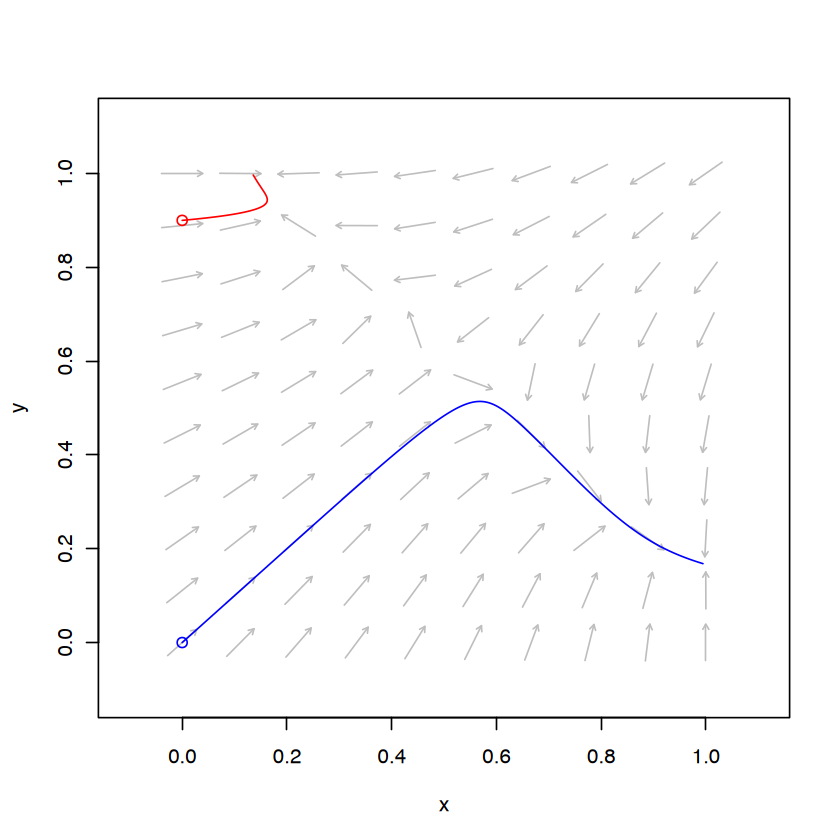

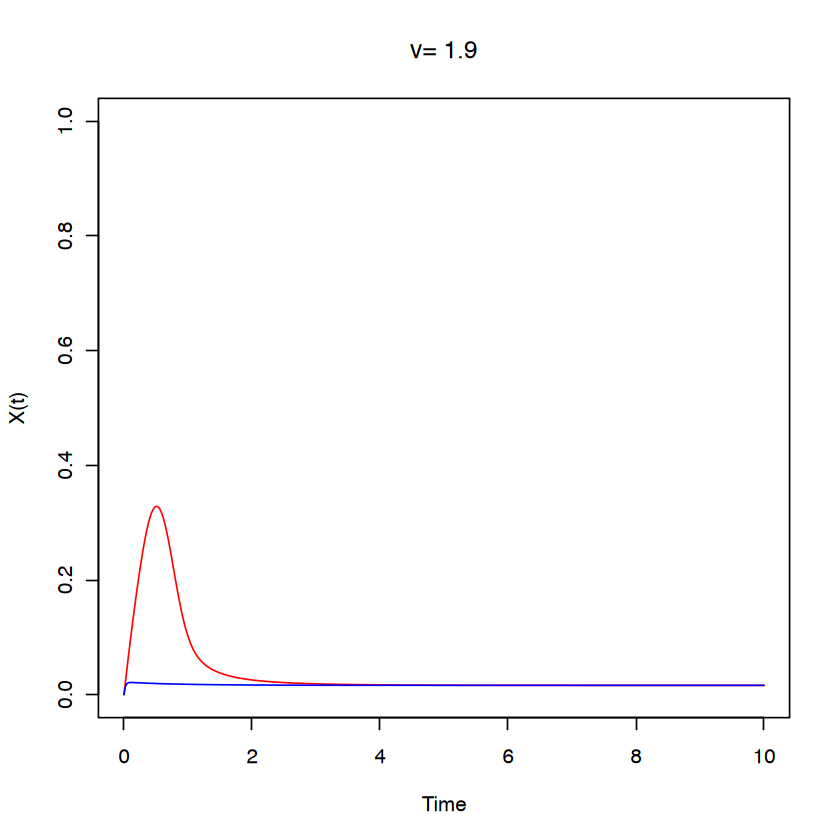

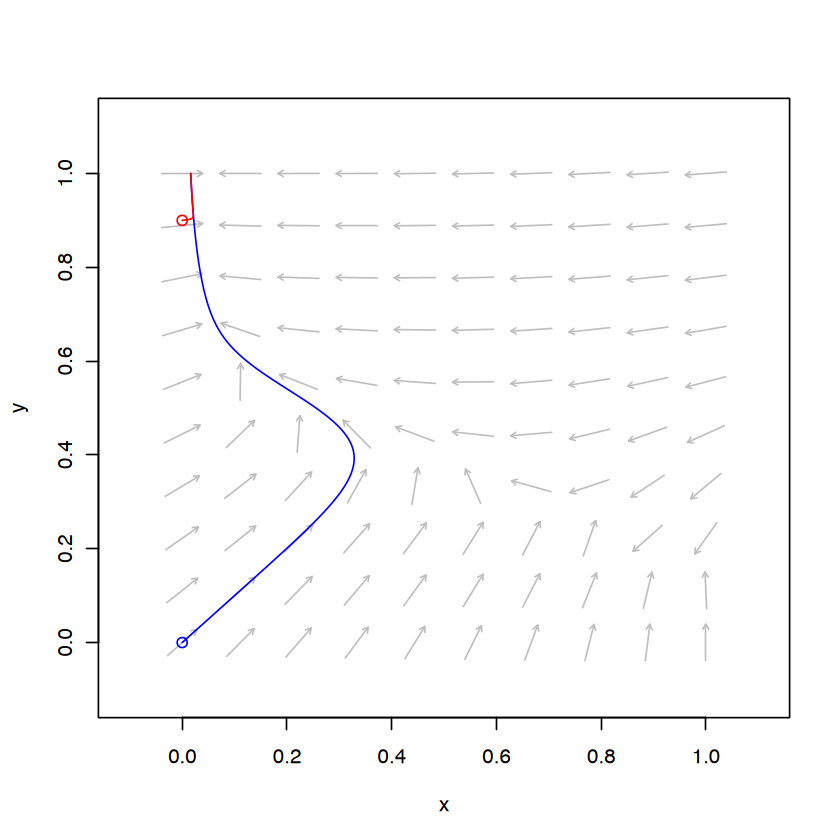

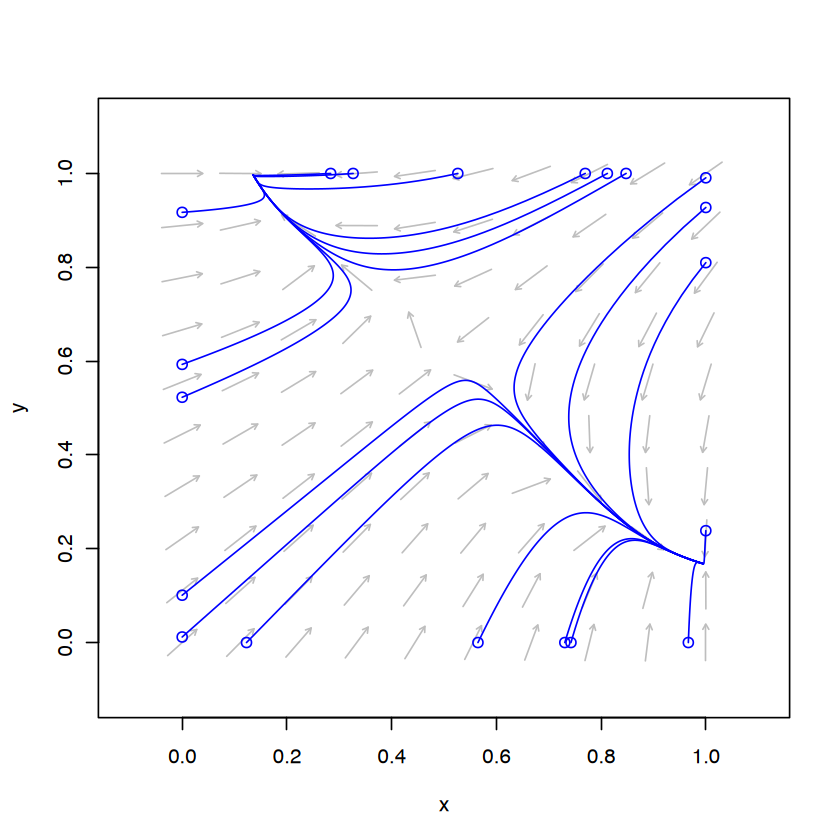

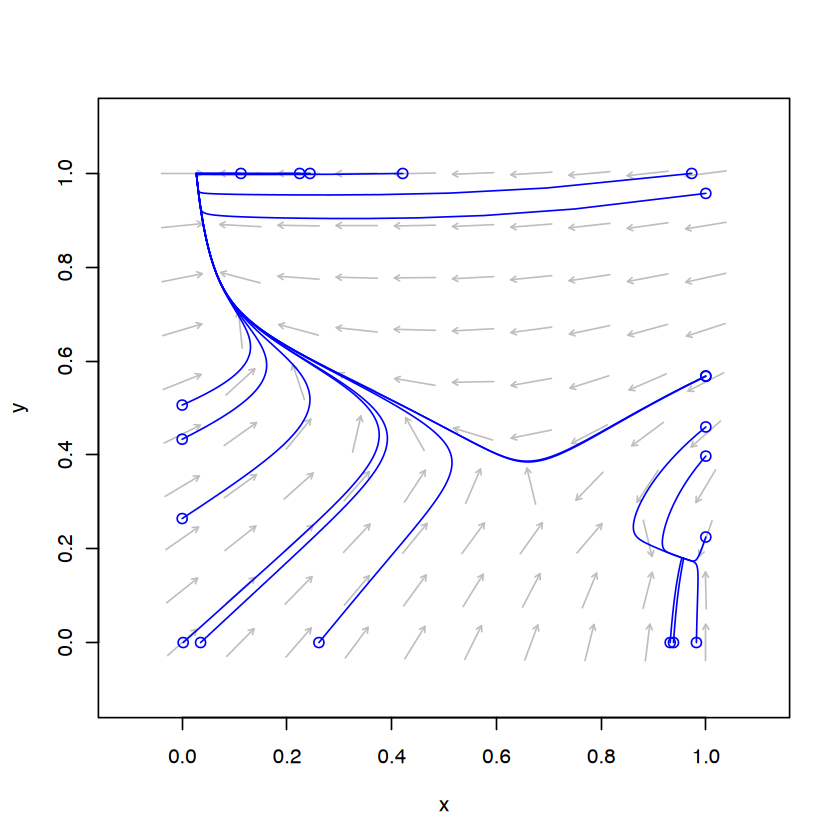

grind.R was sourced


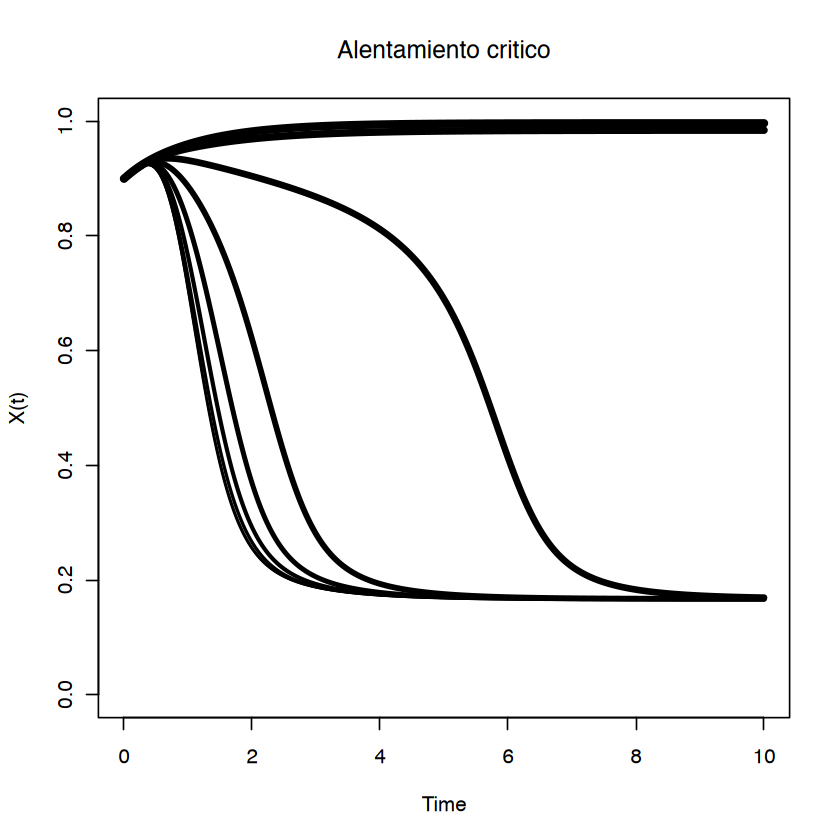

        x         y 
0.5057743 0.6195077 
Unstable point, eigenvalues:  -4.795959 1.204608 
        x         y 
0.9946980 0.1681565 
Stable point, eigenvalues:  -5.989611 -0.9625594 
        x         y 
0.1357302 0.9966187 
Stable point, eigenvalues:  -7.419698 -0.9512533 
Starting at v = 1 with:
        x         y 
0.1357302 0.9966187 


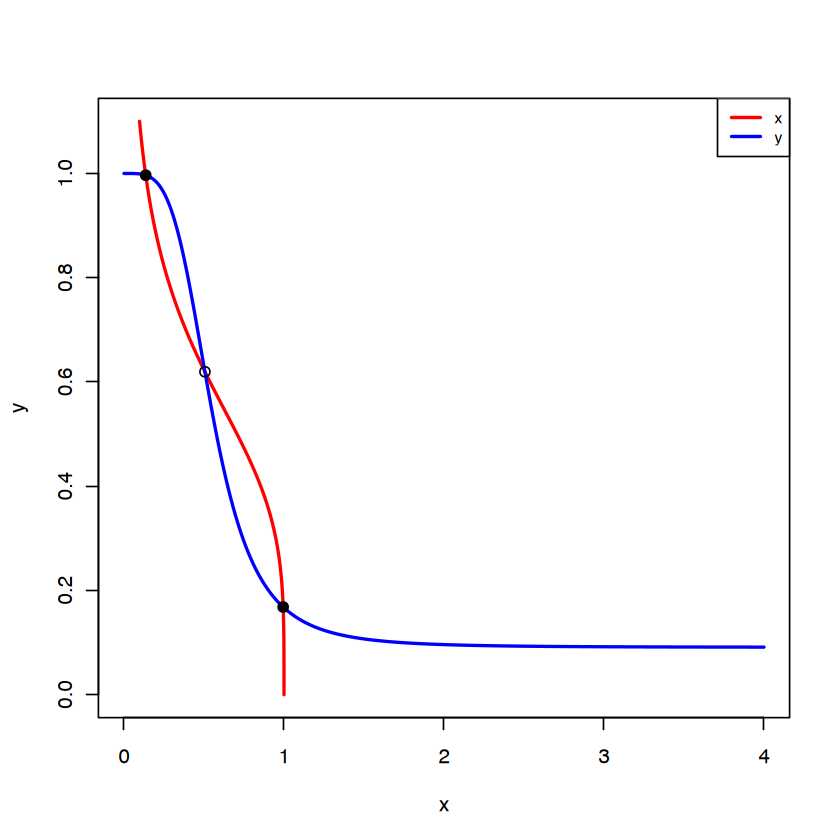

Starting at v = 1 with:
        x         y 
0.9946980 0.1681565 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Starting at v = 1 with:
        x         y 
0.5057743 0.6195077 
Final point at v = 1.796859 
If this looks wrong try changing the step size
Final point at v = 0.8315781 
If this looks wrong try changing the step size


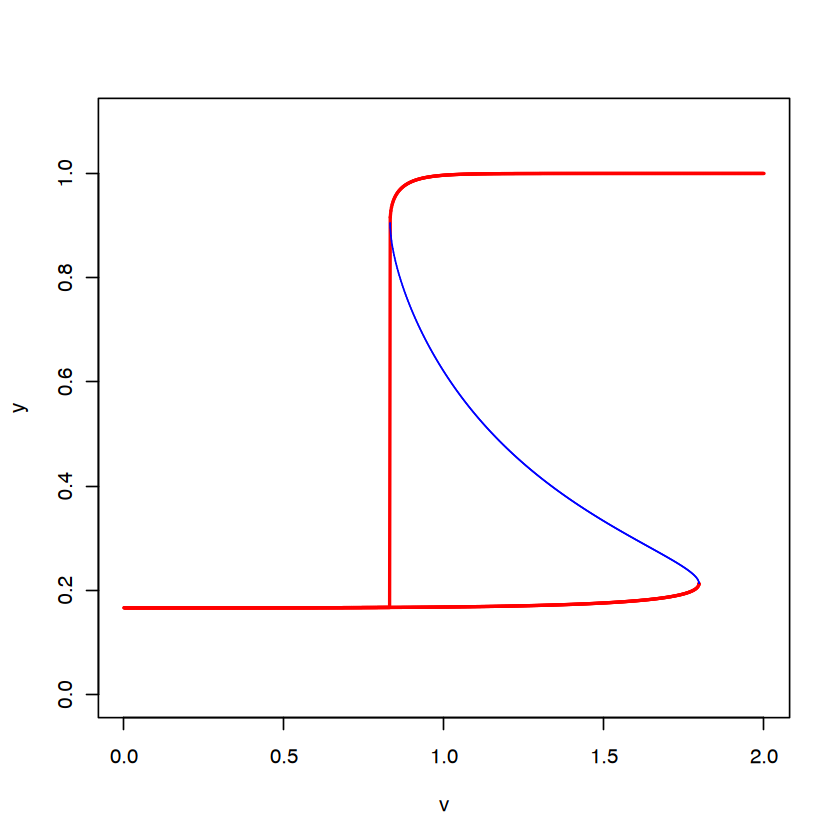

In [14]:
### Praatica 2: Analisis de un sistma de ecuaciones diferenciales acopladas y no lineales:

##. Angeli, D., Ferrell, J. E. & Sontag, E. D. Detection of multistability, bifurcations, and hysteresis in a large class of biological positive-feedback systems. PNAS 101, 1822-7 (2004).

# Borramos todo
#rm(list=ls())

# Nos ubicamos donde queremos
# 2 - Sistemas de ecuaciones diferenciales ordinarias (EDH)")


# Instalar la paqueteria que necesitamos
library(deSolve)
library(phaseR)

# Declarar los valores de par嫥etros que permanecen constantes
alpha1=1; alpha2=1; beta1=200; beta2=10; gamma1=4; gamma2=4; 
K1=30; K2=1;
#v=1;

Angeli2004 <- function(t, y, parms){  
    #         1      2       3      4       5     6      7   8   9
  #parms=(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
         dX <- parms[1]*(1-y[1])-parms[3]*y[1]*(parms[9]*y[2])^parms[5]/(parms[7]+(parms[9]*y[2])^parms[5]);  
         dY <- parms[2]*(1-y[2])-parms[4]*y[2]*y[1]^parms[6]/(parms[8]+y[1]^parms[6]);
         list(c(dX,dY))
}

# Condiciones iniciales
ini_1 <- c(0,0); ini_2 <- c(0,0.9)

# Tiempo de integracion
tspan <- seq(from = 0, to = 10, by = 0.01)

############## PREGUNTA 1: DINAMICA DEL SISTEMA ######################

# parametro de bifurcacion - 
for (v in c(0.75, 1, 1.9)){
 
 parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)

# ， integrar!
out1 <- ode(y = ini_1, times = tspan, func = Angeli2004, parms = parms)

plot(out1[,1], out1[,2],type = "l", ylim=c(0,1),col="red", xlab = "Time", ylab = "X(t)", main = paste("v=", toString(v), sep=" "))

#Ahora con la segunda condicion inicial
out2 <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
lines(out2[,1], out2[,2],type = "l", col="blue")
legend=c(paste("I.C.=", toString(ini_1), sep=" "), paste("I.C.=", toString(ini_2), sep=" "))

# A鎙damos a este diagrama de espacio fase un campo vectorial
Angeli2004.flowField <- flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = FALSE)
Angeli2004.trajectory <- trajectory(Angeli2004, y0 = ini_1, tlim = c(0,10), parameters = parms, col = "blue")
Angeli2004.trajectory <- trajectory(Angeli2004, y0 = ini_2, tlim = c(0,10), parameters = parms, col = "red")
}

############ PREGUNTA 2: Cuencas de atraccion ###############

  # parametro de bifurcacion - 
  for (v in c(1, 1.6)){
    parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
    
    # Añadamos a este diagrama de espacio fase un campo vectorial
    flowField(Angeli2004, xlim = c(0, 1), ylim = c(0, 1), parameters = parms, points = 10, add = FALSE)
    
    # Genera n condiciones iniciales al azar, pero sobre el margen ([x=0,1; y=rand] y vice versa)
    for (ii in seq(1,20,1) ){
      # generate 3 random numbers
      r1=runif(1); r2=runif(1); r3=runif(1);
      
      if (r1<0.5){
      ini = c(as.numeric(r2<0.5), r3)
      } else {
      ini = c(r3, as.numeric(r2<0.5))
      }
      
    trajectory(Angeli2004, y0 = ini, tlim = c(0,10), parameters = parms, col = "blue")
    }
  }



############ PREGUNTA 3: Señales de alerta temprana ###############

LineWidth=1
# parametro de bifurcacion - 
for (v in seq(0.2,1,0.1)){
  
  parms=c(alpha1, alpha2, beta1, beta2, gamma1, gamma2, K1, K2, v)
  
  # ， integrar!
  out <- ode(y = ini_2, times = tspan, func = Angeli2004, parms = parms)
  
  if (v==0.2){
  plot(out[,1], out[,3],type = "l", ylim=c(0,1),col="black", xlab = "Time", ylab = "X(t)", lwd=LineWidth, main="Alentamiento critico" )
  } else {
  lines(out[,1], out[,3],type = "l", col="black", lwd=LineWidth)
  }
  
  LineWidth=LineWidth+0.5
  
}
  

############## PREGUNTA 4: Diagrama de bifurcacion ######################

# Corre el codigo anexo:
source('Grind.r') # puedes hacerlo abriendolo y corriendolo, o ir a la carpeta en la que esto con setwd(..) y luego


# Declarar los valores de parametros que permanecen constantes
alpha1=1; alpha2=1; beta1=200; beta2=10; gamma1=4; gamma2=4; 
K1=30; K2=1;
#v=1;

model <- function(t, state, parms){  
  with(as.list(c(state,parms)), {
    dx = alpha1*(1-x)-beta1*x*(v*y)^gamma1/(K1+(v*y)^gamma1)
    dy = alpha2*(1-y)-beta2*y*x^gamma2/(K2+x^gamma2)
    return(list(c(dx, dy)))
  })
}
  

p <-  c(alpha1=1, alpha2=1, beta1=200, beta2=10, gamma1=4, gamma2=4, K1=30, K2=1, v=1)
s <- c(x=0,y=0)
plane(xmax=4)
mid <- newton(s,plot=T)
low <- newton(c(x=1,y=0),plot=T)
hig <- newton(c(x=0,y=1),plot=T)

continue(state=hig, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1) # log="", time=0, positive=TRUE, add=TRUE)
continue(state=low, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1, log="", time=0, positive=TRUE, add=TRUE)
continue(state=mid, parms=p, odes=model, x="v", step=0.001, xmin=0, xmax=2,y="y", ymin=0, ymax=1.1, log="", time=0, positive=TRUE, add=TRUE)


